In [25]:
from Functions.Graphs import *
from Functions.Utils import *
from scipy.signal import stft
from scipy.signal import hilbert
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import re
fs = 25600

def PlotSTFT(x,fs,nperseg=1024,noverlap=None):
    
    t = np.arange(len(x))*(1/fs)

    x_env = hilbert(x)
    x_env = np.abs(x_env)
    f, t_segment, Zxx = stft(x, fs=fs, nperseg=nperseg,noverlap=noverlap)
    f2, t_segment2, Zxx2 = stft(x_env, fs=fs, nperseg=nperseg,noverlap=noverlap)
    Zxx = np.abs(Zxx)
    Zxx2 = np.abs(Zxx2)
    # 2. Criação da Estrutura com Subplots Lado a Lado
    fig = make_subplots(
        rows=1, cols=2,
        shared_xaxes=True,
        subplot_titles=('Espectrograma STFT (Sinal Bruto)', 'Espectrograma STFT (Envelope)'),
        horizontal_spacing=0.08
    )

    # 3. Adiciona o primeiro Espectrograma (Sinal Original)
    fig.add_trace(
        go.Heatmap(
            z=Zxx,
            x=t_segment,
            y=f,
            colorscale='Viridis',
            zsmooth='fast',  # Equivalente ao shading='gouraud' do Matplotlib
            showscale=False  # Mantém a Colorbar apenas no segundo subplot para não poluir
        ),
        row=1, col=1
    )

    # 4. Adiciona o segundo Espectrograma (Envelope)
    fig.add_trace(
        go.Heatmap(
            z=Zxx2,
            x=t_segment2,
            y=f2,
            colorscale='Viridis',
            zsmooth='fast',
            colorbar=dict(
                title='Magnitude',
                len=1.0  # Ajusta a altura da barra lateral de cores
            )
        ),
        row=1, col=2
    )

    # 5. Configuração Geral do Layout e Rótulos dos Eixos
    fig.update_layout(
        title_text="Análise de Espectrogramas STFT",
        template="plotly_white",
        width=1200,
        height=500,
        margin=dict(t=80, b=50, l=60, r=60)
    )

    # Rótulos dos Eixos X e Y para ambos os subplots
    fig.update_xaxes(title_text="Tempo (Segundos)", row=1, col=1)
    fig.update_xaxes(title_text="Tempo (Segundos)", row=1, col=2)

    fig.update_yaxes(title_text="Frequência (Hz)", row=1, col=1)
    fig.update_yaxes(title_text="Frequência (Hz)", row=1, col=2)

    fig.show()
    

In [ ]:
path = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU_Bearing\B1_2\160.csv'
df = pd.read_csv(path)
x = df['Horizontal_vibration_signals'].values
x = x - np.mean(x)
PlotSTFT(x,fs,nperseg=256,noverlap=None)


In [ ]:
nperseg=256
noverlap=None
t = np.arange(len(x))*(1/fs)

x_env = hilbert(x)
x_env = np.abs(x_env)
f, t, Z = stft(x, fs=fs, nperseg=nperseg,noverlap=noverlap)
f2, t2, Z2 = stft(x_env, fs=fs, nperseg=nperseg,noverlap=noverlap)
sigs = [np.abs(Z),np.abs(Z2)]
for Z in sigs:
    col_names = [f'{val/1000:.2f} kHz' for val in f]
    data_dict = {'time (s)': t}
    Z_data = Z.T if Z.shape[0] == len(f) else Z

    for i, name in enumerate(col_names):
        data_dict[name] = Z_data[:, i]
    df2 = pd.DataFrame(data_dict)
    print(df2.shape)
    #print(df2.head())

In [28]:
path = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU_Bearing\B1_2\Raw\160.csv'
#df = pd.read_csv(path)

def CalculateSTFT(df,fs=25600,horizontal=True,env=False,nperseg=256,noverlap=None):
    if horizontal:
        x = df.iloc[:,0].values
    else:
        x = df.iloc[:,1].values
    if env:
        x = hilbert(x)
        x = np.abs(x)
    else:
        None
    f, t, Z = stft(x, fs=fs, nperseg=nperseg,noverlap=noverlap)
    Z = np.abs(Z)
    col_names = [f'{val/1000:.2f} kHz' for val in f]
    data_dict = {'time (s)': t}
    Z_data = Z.T if Z.shape[0] == len(f) else Z
    for i, name in enumerate(col_names):
        data_dict[name] = Z_data[:, i]
    df2 = pd.DataFrame(data_dict)
    return df2


In [50]:
path = f'C:/Users/Claudio/Desktop/Python/Datasets/XJTU_Bearing/Raw'
brngs = os.listdir(path)
brngs

['B1_1',
 'B1_2',
 'B1_3',
 'B1_4',
 'B1_5',
 'B2_1',
 'B2_2',
 'B2_3',
 'B2_4',
 'B2_5']

In [52]:
path = f'C:/Users/Claudio/Desktop/Python/Datasets/XJTU_Bearing/Raw'
brngs = os.listdir(path)
for brng in brngs:
    #if not brng.startswith('B2_'): continue
    path_in = f'C:/Users/Claudio/Desktop/Python/Datasets/XJTU_Bearing/Raw/{brng}'
    path_out = f'Dataset/XJTU/STFT/{brng}'
    def CalculateDfSTFT(path_in,path_out,fs=25600,horizontal=True,env=False,nperseg=256,noverlap=None):
        if env:
            path_out = path_out+'_env'
        os.makedirs(path_out,exist_ok=True)
        samples = os.listdir(path_in)
        samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
        for sample in samples:
            sample_path = os.path.join(path_in,sample)
            df = pd.read_csv(sample_path)
            df2 = CalculateSTFT(df,fs,horizontal,env,nperseg,noverlap)
            sample_out = os.path.join(path_out,sample)
            df2.to_csv(sample_out,index=False)
            # print(sample_path)
        print(sample_out)
    CalculateDfSTFT(path_in,path_out,env=True)

Dataset/XJTU/STFT/B1_1_env\123.csv
Dataset/XJTU/STFT/B1_2_env\161.csv
Dataset/XJTU/STFT/B1_3_env\158.csv
Dataset/XJTU/STFT/B1_4_env\122.csv
Dataset/XJTU/STFT/B1_5_env\52.csv
Dataset/XJTU/STFT/B2_1_env\491.csv
Dataset/XJTU/STFT/B2_2_env\161.csv
Dataset/XJTU/STFT/B2_3_env\533.csv
Dataset/XJTU/STFT/B2_4_env\42.csv
Dataset/XJTU/STFT/B2_5_env\339.csv


In [42]:
def build_pure_convolutional_encoder(input_shape=(25600, 1), latent_dim=128):
    """
    Constrói apenas o Extrator de Características (Encoder) sem as cabeças
    de decisão. Transforma (25600, 1) em um vetor latente de (latent_dim,).
    """
    inputs = layers.Input(shape=input_shape, name="raw_vibration_input")
    
    # Camada 1: Filtro longo (64) para varrer dinâmicas macro do sinal mecânico
    x = layers.Conv1D(filters=32, kernel_size=128, strides=4, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=4)(x)
    
    # Camada 2: Filtros intermediários (16) para transientes e choques repetitivos
    x = layers.Conv1D(filters=64, kernel_size=32, strides=4, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    # Camada 3: Filtros curtos (5) para extrair micro-assinaturas de modulação
    x = layers.Conv1D(filters=latent_dim, kernel_size=5, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    # Redução espacial final: Extrai a média global de energia de cada um dos 128 filtros
    latent_space = layers.GlobalAveragePooling1D(name="extracted_features")(x)
    
    # Define o modelo contendo apenas a estrutura de extração
    encoder_model = Model(inputs=inputs, outputs=latent_space, name="Vibration_Encoder_1D")
    
    return encoder_model


In [45]:
nfeatures = 16
path = r'Dataset\XJTU\STFT'
brngs = os.listdir(path)[:]
#brngs.sort(key=lambda x: int(re.search(r'\d+', x).group()))
for i,brng in enumerate(brngs[:]):
#for i,brng in enumerate(brngs[::-1]):
    if not brng.startswith('B1_'): continue
    print(brng)
    brng_path = os.path.join(path,brng)
    samples = os.listdir(brng_path)
    samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
    X = []
    for sample in samples:
        df = pd.read_csv(os.path.join(brng_path, sample))
        sig = df.iloc[:,1:].values
        X.append(sig)
    X = np.array(X)
    if i==0:
        encoder = build_pure_convolutional_encoder(input_shape=sig.shape, latent_dim=nfeatures)
    Z = encoder.predict(X)
    df = pd.DataFrame(Z)
    df.columns = [f'F{j+1}' for j in range(nfeatures)]
    out = f'Dataset/XJTU/DSI3_STFT/'
    os.makedirs(out,exist_ok=True)
    print(out+f'{brng}.csv')
    df.to_csv(out+f'{brng}.csv',index=False)

B1_1
4/4 [==============================] - 0s 7ms/step
Dataset/XJTU/DSI3_STFT/B1_1.csv
B1_2
6/6 [==============================] - 0s 6ms/step
Dataset/XJTU/DSI3_STFT/B1_2.csv
B1_3
5/5 [==============================] - 0s 7ms/step
Dataset/XJTU/DSI3_STFT/B1_3.csv
B1_4
4/4 [==============================] - 0s 6ms/step
Dataset/XJTU/DSI3_STFT/B1_4.csv
B1_5
2/2 [==============================] - 0s 5ms/step
Dataset/XJTU/DSI3_STFT/B1_5.csv


In [48]:
X.shape

(52, 257, 129)

In [47]:
Z.shape

(52, 16)

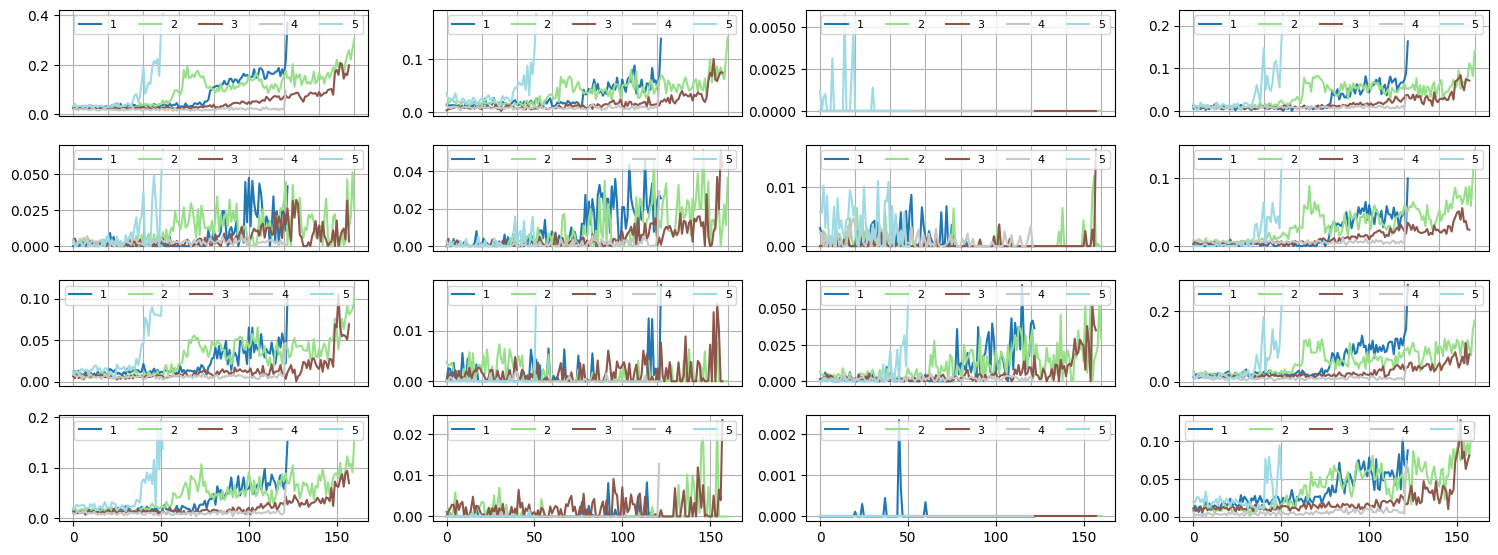

In [46]:
path = r'Dataset\XJTU\DSI3_STFT'
brngs = os.listdir(path)[:]
dfs = []
for brng in brngs:
    brng_path = os.path.join(path,brng)
    df = pd.read_csv(brng_path)
    dfs.append(df)
PlotDataframes(dfs,w=15,h=6)

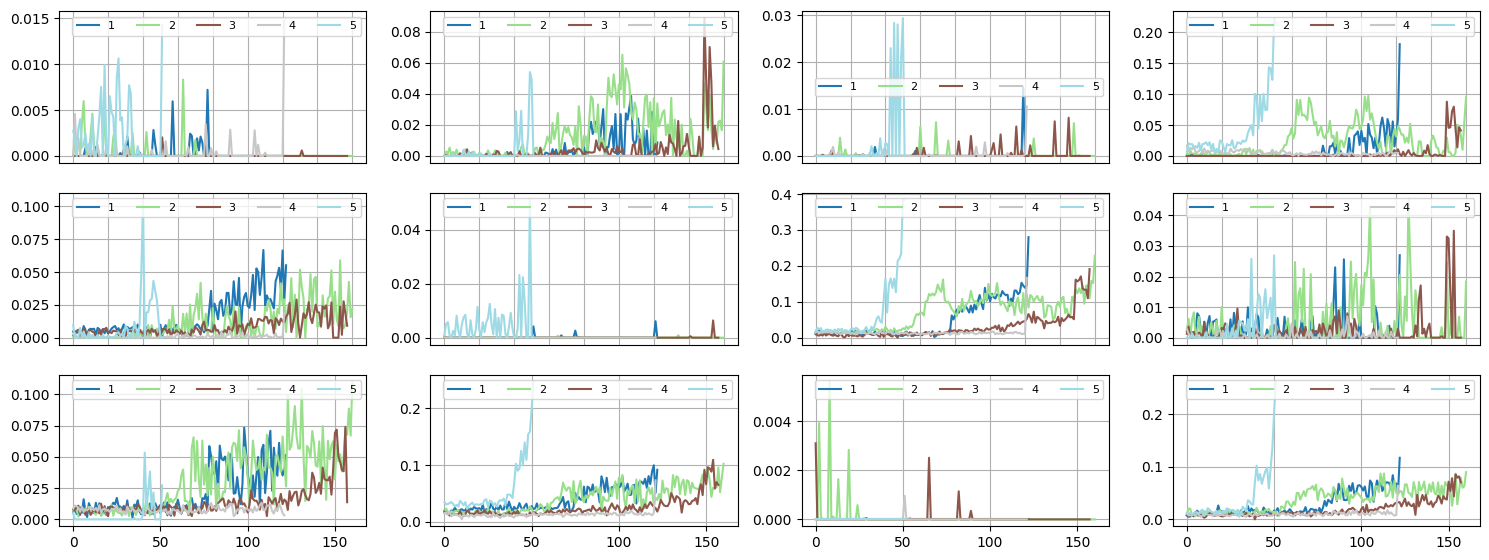

In [44]:
path = r'Dataset\XJTU\DSI3_STFT'
brngs = os.listdir(path)[:]
dfs = []
for brng in brngs:
    brng_path = os.path.join(path,brng)
    df = pd.read_csv(brng_path)
    dfs.append(df)
PlotDataframes(dfs,w=15,h=6)